# Veridi Logistics Delivery Performance Audit

**Author:** Andrew Osei-Wusu

# 1. Project Overview

## Executive Summary

This analysis investigates delivery performance across Veridi Logistics using the Olist e-commerce dataset.

The primary objective is to determine whether delivery delays and inaccurate delivery estimates are contributing to declining customer satisfaction.

Key findings show that while 93.23% of deliveries are completed on time, late deliveries have a significant negative impact on customer ratings. Orders delivered late receive substantially lower review scores, confirming a strong operational-customer experience link.

Geographic analysis reveals that delivery performance varies significantly by state, indicating that logistics inefficiencies are not uniform but regionally concentrated.

Overall, the findings suggest that delivery delay management is a critical driver of customer satisfaction and should be treated as a core operational KPI rather than a secondary metric.

# *Objective:*
*To investigate whether inaccurate delivery estimates are contributing to negative customer reviews and identify the regions most affected by delivery delays.*

# 2. Import Libraries

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

os.listdir('/content/drive/MyDrive')

['Copy of ALX Professional Foundations - Skills Tracker (2).gsheet',
 'Copy of Professional Foundations - Week 1 Milestone Rubric.gdoc',
 'Copy of PICS and Personal Mission Statement Worksheet - ALX Foundations (1).gdoc',
 'Copy of ALX Professional Foundations - Skills Tracker (1).gsheet',
 'Copy of ALX Professional Foundations - Skills Tracker.gsheet',
 'Copy of Professional Foundations - Week 2 Milestone Rubric.gdoc',
 'Copy of PICS and Personal Mission Statement Worksheet - ALX Foundations.gdoc',
 'Untitled document (1).gdoc',
 'ALX PF Course',
 'Andrew Osei-Wusu_CV.pdf',
 'Copy of Professional Foundations - Week 3 Milestone Rubric (2).gdoc',
 'Copy of Google Workspace Skills Checklist_ ALX Foundations.gsheet',
 'Copy of Week 3 Milestone Worksheet - Professional Foundations (1).gdoc',
 'Copy of Professional Foundations - Week 3 Milestone Rubric (1).gdoc',
 'Copy of Professional Foundations - Week 3 Milestone Rubric.gdoc',
 'Copy of Week 3 Milestone Worksheet - Professional Foundatio

In [3]:
os.listdir('/content/drive/MyDrive/AmaliTech_2026_NSS')

['Veridi_Logistics_Audit']

In [4]:
os.listdir('/content/drive/MyDrive/AmaliTech_2026_NSS/Veridi_Logistics_Audit/data')

['olist_customers_dataset.csv',
 'olist_order_items_dataset.csv',
 'olist_order_payments_dataset.csv',
 'olist_geolocation_dataset.csv',
 'olist_order_reviews_dataset.csv',
 'olist_products_dataset.csv',
 'olist_orders_dataset.csv',
 'product_category_name_translation.csv',
 'olist_sellers_dataset.csv']

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

In [6]:
DATA_PATH = "/content/drive/MyDrive/AmaliTech_2026_NSS/Veridi_Logistics_Audit/data/"

# 3. Load Datasets

In [7]:
orders = pd.read_csv(DATA_PATH + "olist_orders_dataset.csv")

reviews = pd.read_csv(DATA_PATH + "olist_order_reviews_dataset.csv")

customers = pd.read_csv(DATA_PATH + "olist_customers_dataset.csv")

products = pd.read_csv(DATA_PATH + "olist_products_dataset.csv")

translations = pd.read_csv(DATA_PATH + "product_category_name_translation.csv")

In [8]:
print("Orders:", orders.shape)
print("Reviews:", reviews.shape)
print("Customers:", customers.shape)
print("Products:", products.shape)
print("Translations:", translations.shape)

Orders: (99441, 8)
Reviews: (99224, 7)
Customers: (99441, 5)
Products: (32951, 9)
Translations: (71, 2)


# 4. Data Inspection

### Initial Dataset Overview

The Orders, Reviews, and Customers datasets contain approximately 99,000 records each, indicating substantial coverage of customer transactions. The Products dataset contains over 32,000 products, while the translation table provides English mappings for 71 product categories. The datasets appear sufficiently comprehensive for analyzing delivery performance, customer sentiment, and regional trends.

In [9]:
orders.info()
reviews.info()
customers.info()
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  ob

### Data Structure Observations
The Orders dataset contains key transaction and delivery information, including purchase, approval, estimated delivery, and actual delivery timestamps. Several delivery-related fields contain missing values, primarily for orders that were not completed or delivered.

The Reviews dataset stores customer feedback and review scores. While review scores are fully populated, textual review fields contain substantial missing values, indicating that many customers provided ratings without written comments.

The Customers dataset is complete with no missing values and provides geographic information such as customer city and state, which will support regional delivery performance analysis.

The Products dataset contains product characteristics and dimensions. A small number of records have missing product category and physical attribute information, which may require attention when performing product-level analysis.

# 5. Data Cleaning

In [10]:
orders.isnull().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,160
order_delivered_carrier_date,1783
order_delivered_customer_date,2965
order_estimated_delivery_date,0


In [11]:
reviews.isnull().sum()

,0
review_id,0
order_id,0
review_score,0
review_comment_title,87656
review_comment_message,58247
review_creation_date,0
review_answer_timestamp,0


In [12]:
products.isnull().sum()

,0
product_id,0
product_category_name,610
product_name_lenght,610
product_description_lenght,610
product_photos_qty,610
product_weight_g,2
product_length_cm,2
product_height_cm,2
product_width_cm,2


### Missing Value Assessment
The Orders dataset contains missing values primarily in delivery-related timestamp fields. These missing values are expected for orders that were canceled, unavailable, or not yet delivered.

The Reviews dataset has complete review scores but a large proportion of missing review titles and review messages. Since sentiment analysis in this project relies on the numerical review score, these missing text fields do not significantly affect the analysis.

The Products dataset contains a small number of missing product attributes and category names. These fields are not critical for the core delivery performance analysis but may require attention for product-level investigations.

### Date Formatting

In [13]:
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_columns:
    orders[col] = pd.to_datetime(orders[col])

In [14]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.1+ MB


### Date Conversion Results

All order-related date fields were successfully converted from text format to datetime format. This enables accurate calculation of delivery delays, lead times, and other time-based performance metrics required for the analysis.

In [15]:
orders["order_id"].duplicated().sum()

np.int64(0)

In [16]:
customers["customer_id"].duplicated().sum()

np.int64(0)

In [17]:
reviews["order_id"].duplicated().sum()

np.int64(551)

### Duplicate Record Assessment
The Orders and Customers datasets contain no duplicate key records, indicating that each order and customer is uniquely represented. However, the Reviews dataset contains 551 duplicate order IDs, meaning that some orders received multiple review entries. To preserve a one-to-one relationship during table integration and prevent row duplication, only one review record per order will be retained.

### Review Data Standardization

In [18]:
reviews["review_creation_date"] = pd.to_datetime(
    reviews["review_creation_date"]
)

In [19]:
reviews_clean = (
    reviews
    .sort_values("review_creation_date")
    .drop_duplicates(
        subset="order_id",
        keep="last"
    )
)

In [20]:
reviews_clean["order_id"].duplicated().sum()

np.int64(0)

In [21]:
print("Original Reviews:", reviews.shape)
print("Clean Reviews:", reviews_clean.shape)

Original Reviews: (99224, 7)
Clean Reviews: (98673, 7)


Duplicate review records were standardized by retaining the most recent review for each order. This approach ensures a one-to-one relationship between orders and reviews, preventing duplication during data integration while preserving the latest customer sentiment.

# 6. Data Integration

### Building the Master Dataset

In [22]:
orders_customers = orders.merge(
    customers,
    on="customer_id",
    how="left"
)

In [23]:
orders_customers.shape

(99441, 12)

In [24]:
master_df = orders_customers.merge(
    reviews_clean,
    on="order_id",
    how="left"
)

In [25]:
master_df.shape

(99441, 18)

In [26]:
print("Orders rows:", len(orders))
print("Master rows:", len(master_df))

Orders rows: 99441
Master rows: 99441


In [27]:
master_df["order_id"].duplicated().sum()

np.int64(0)



The Orders, Customers, and Reviews datasets were successfully integrated into a single master dataset. Row counts remained unchanged after the joins, confirming that no unintended duplication occurred. The resulting dataset contains order details, customer location information, and customer review scores at the order level, providing a unified foundation for delivery performance and sentiment analysis.

# 7. Delivery Delay Analysis

### Preparing Delivered Orders

In [28]:
master_delivered = master_df[
    master_df["order_delivered_customer_date"].notna()
].copy()

In [29]:
master_delivered.shape

(96476, 18)

### Calculating Delivery Delays

In [30]:
master_delivered["days_difference"] = (
    master_delivered["order_delivered_customer_date"]
    - master_delivered["order_estimated_delivery_date"]
).dt.days

In [31]:
master_delivered["days_difference"].describe()

,days_difference
count,96476.000000
mean,-11.876881
std,10.183854
min,-147.000000
25%,-17.000000
50%,-12.000000
75%,-7.000000
max,188.000000


A total of 96,476 delivered orders were available for delivery performance analysis. The average delivery occurred approximately 12 days before the estimated delivery date, indicating that most orders were delivered earlier than promised. However, the presence of positive delay values, with some orders arriving up to 188 days late, suggests that a subset of customers experienced substantial delivery delays.

### Delivery Status Classification

In [32]:
def classify_delivery(delay):
    if delay <= 0:
        return "On Time"
    elif delay <= 5:
        return "Late"
    else:
        return "Super Late"

In [33]:
master_delivered["delivery_status"] = (
    master_delivered["days_difference"]
    .apply(classify_delivery)
)

In [34]:
master_delivered["delivery_status"].value_counts()

,count
delivery_status,
On Time,89941
Super Late,3765
Late,2770


In [35]:
round(
    master_delivered["delivery_status"]
    .value_counts(normalize=True) * 100,
    2
)

,proportion
delivery_status,
On Time,93.23
Super Late,3.90
Late,2.87


Based on the delivery delay classification, 93.23% of delivered orders arrived on or before the estimated delivery date. However, 6.77% of orders were delivered late, including 3.90% that were classified as Super Late (more than five days after the promised delivery date). While the overall delivery performance appears strong, a notable subset of customers experienced significant delays that may negatively affect customer satisfaction.

### Delivery Performance Distribution

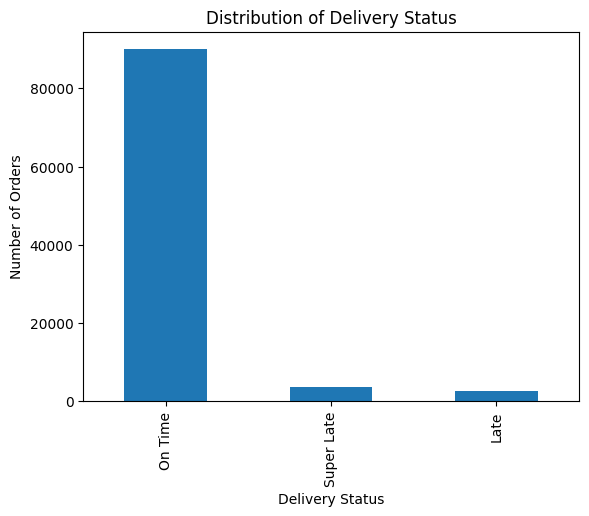

In [36]:
master_delivered["delivery_status"].value_counts().plot(
    kind="bar"
)

plt.title("Distribution of Delivery Status")
plt.xlabel("Delivery Status")
plt.ylabel("Number of Orders")
plt.show()

The distribution shows that most deliveries were completed on time. Nevertheless, the volume of late and super-late deliveries remains substantial when viewed in absolute terms, affecting thousands of customers and warranting further investigation into geographic and operational factors.

# 8. Geographic Performance Analysis

### Late Delivery Rates by State

In [37]:
master_delivered["is_late"] = (
    master_delivered["days_difference"] > 0
)

In [38]:
state_performance = (
    master_delivered
    .groupby("customer_state")["is_late"]
    .mean()
    * 100
)

state_performance = (
    state_performance
    .sort_values(ascending=False)
)

state_performance.head(10)

,is_late
customer_state,
AL,21.410579
MA,17.433752
SE,15.223881
PI,13.865546
CE,13.760751
RR,12.195122
BA,12.162162
RJ,12.102323
PA,11.205074


The analysis reveals substantial regional differences in delivery performance. States such as AL, MA, and SE exhibit late delivery rates that are significantly higher than the overall average late-delivery rate of 6.77%. These findings suggest that delivery delays are concentrated in specific regions rather than being a uniform nationwide issue.

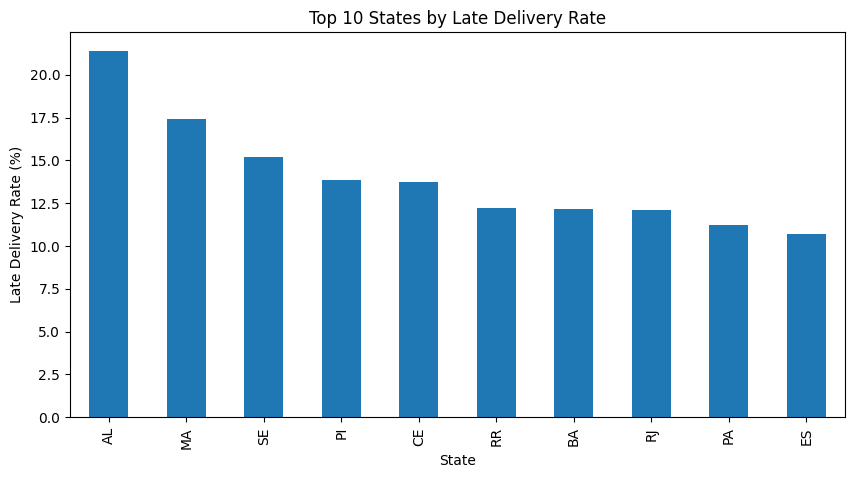

In [39]:
plt.figure(figsize=(10,5))

state_performance.head(10).plot(
    kind="bar"
)

plt.title("Top 10 States by Late Delivery Rate")
plt.xlabel("State")
plt.ylabel("Late Delivery Rate (%)")
plt.show()

The visualization highlights a clear performance gap between states. Several regions experience late delivery rates that are nearly two to three times higher than the overall company average, indicating potential logistical bottlenecks, transportation challenges, or geographic constraints.

### Regional Delivery Risk Assessment

In [40]:
state_performance.describe()

,is_late
count,27.000000
mean,9.146087
std,4.767757
min,2.758621
25%,5.126279
50%,9.604520
75%,12.132243
max,21.410579


Delivery performance varies substantially across states. Late-delivery rates range from approximately 2.8% to 21.4%, demonstrating significant geographic disparities. This variation suggests that operational challenges are concentrated in specific regions rather than affecting all customers equally, making targeted intervention more effective than a nationwide response.

# 9. Customer Sentiment Analysis

### Review Scores by Delivery Status

In [41]:
master_delivered.groupby(
    "delivery_status"
)["review_score"].mean().sort_values(
    ascending=False
)

,review_score
delivery_status,
On Time,4.290135
Late,2.989346
Super Late,1.736612


Customer satisfaction decreases significantly as delivery delays increase. Orders delivered on time achieved an average review score of 4.29 out of 5, while late deliveries averaged 2.99. Orders classified as Super Late received the lowest average score of 1.74. These results indicate a strong relationship between delivery performance and customer sentiment, suggesting that delayed deliveries are a major driver of negative customer reviews.

### Delivery Delays and Customer Satisfaction

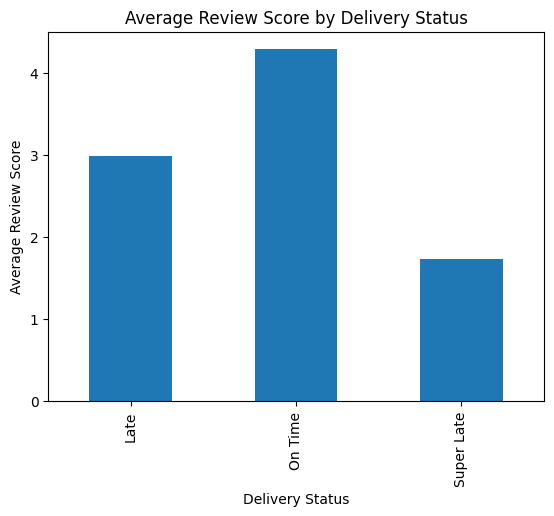

In [42]:
avg_reviews = (
    master_delivered
    .groupby("delivery_status")["review_score"]
    .mean()
)

avg_reviews.plot(kind="bar")

plt.title("Average Review Score by Delivery Status")
plt.xlabel("Delivery Status")
plt.ylabel("Average Review Score")
plt.show()

The visualization demonstrates a clear decline in customer satisfaction as delivery delays become more severe. The pattern suggests that logistics performance has a direct impact on customer experience and brand perception.

### Correlation Between Delay Days and Review Scores

In [43]:
master_delivered[
    ["days_difference", "review_score"]
].corr()

,days_difference,review_score
days_difference,1.000000,-0.266927
review_score,-0.266927,1.000000


The correlation coefficient between delivery delay and review score is -0.267, indicating a negative relationship between delivery delays and customer satisfaction. Although customer ratings are influenced by multiple factors, the results suggest that longer delivery delays are associated with lower review scores and poorer customer experiences.

# 10. Candidate's Choice Analysis
## Product Category Delivery Risk

To extend the core analysis, product categories were evaluated against delivery performance to identify whether certain types of goods are more prone to delays.

The analysis reveals that categories such as furniture, home comfort, and audio products experience higher late delivery rates compared to smaller or less complex items.

This suggests that delivery delays are not only geographically driven but also influenced by product characteristics such as size, handling complexity, and logistics requirements.

From a business perspective, this insight allows Veridi Logistics to prioritize operational improvements for high-risk product categories, rather than applying uniform logistics strategies across all goods.

Optimizing delivery processes for these categories could significantly reduce late deliveries and improve overall customer satisfaction.

### Product Category Delivery Risk Analysis

This analysis investigates whether certain product categories are associated with poorer customer experiences. Understanding category-level performance can help Veridi Logistics identify products that may require specialized handling, packaging, or delivery processes.


In [44]:
order_items = pd.read_csv(
    DATA_PATH + "olist_order_items_dataset.csv"
)

In [45]:
order_items.shape

(112650, 7)

In [46]:
order_items.columns

Index(['order_id', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value'],
      dtype='object')

In [47]:
products.columns

Index(['product_id', 'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm'],
      dtype='object')

In [48]:
translations.columns

Index(['product_category_name', 'product_category_name_english'], dtype='object')

In [49]:
products_translated = products.merge(
    translations,
    on="product_category_name",
    how="left"
)

In [50]:
products_translated.shape

(32951, 10)

In [51]:
products_translated[
    ["product_category_name",
     "product_category_name_english"]
].head()

,product_category_name,product_category_name_english
0,perfumaria,perfumery
1,artes,art
2,esporte_lazer,sports_leisure
3,bebes,baby
4,utilidades_domesticas,housewares


In [52]:
category_df = order_items.merge(
    products_translated[
        [
            "product_id",
            "product_category_name_english"
        ]
    ],
    on="product_id",
    how="left"
)

In [53]:
category_df.shape

(112650, 8)

In [54]:
master_category = master_delivered.merge(
    category_df[
        [
            "order_id",
            "product_category_name_english"
        ]
    ],
    on="order_id",
    how="left"
)

In [55]:
master_category.shape

(110196, 22)

Product category information was integrated into the delivery dataset by linking order items to product records and translating category names into English. Because individual orders can contain multiple products, the resulting category-level dataset contains more rows than the order-level dataset. This structure enables category-specific performance analysis.

### Product Categories with Lowest Review Scores

In [56]:
category_reviews = (
    master_category
    .groupby("product_category_name_english")
    ["review_score"]
    .mean()
    .sort_values()
)

category_reviews.head(10)

,review_score
product_category_name_english,
security_and_services,2.500000
diapers_and_hygiene,3.378378
office_furniture,3.512696
home_comfort_2,3.629630
fixed_telephony,3.757937
fashion_male_clothing,3.758065
party_supplies,3.833333
audio,3.837989
home_confort,3.852459


In [57]:
master_category["is_late"] = (
    master_category["days_difference"] > 0
)

In [58]:
category_late = (
    master_category
    .groupby("product_category_name_english")
    ["is_late"]
    .mean()
    * 100
)

category_late = category_late.sort_values(
    ascending=False
)

category_late.head(10)

,is_late
product_category_name_english,
furniture_mattress_and_upholstery,13.513514
home_comfort_2,13.333333
audio,11.602210
christmas_supplies,10.000000
fashion_underwear_beach,9.448819
home_confort,9.324009
books_technical,7.984791
office_furniture,7.973621
baby,7.679410


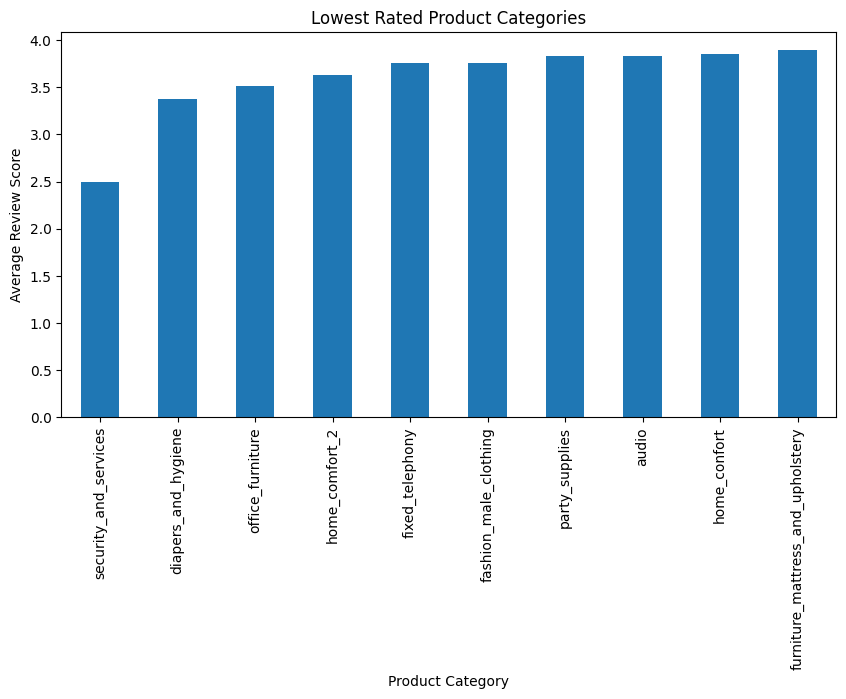

In [59]:
plt.figure(figsize=(10,5))

category_reviews.head(10).plot(
    kind="bar"
)

plt.title("Lowest Rated Product Categories")
plt.ylabel("Average Review Score")
plt.xlabel("Product Category")
plt.show()

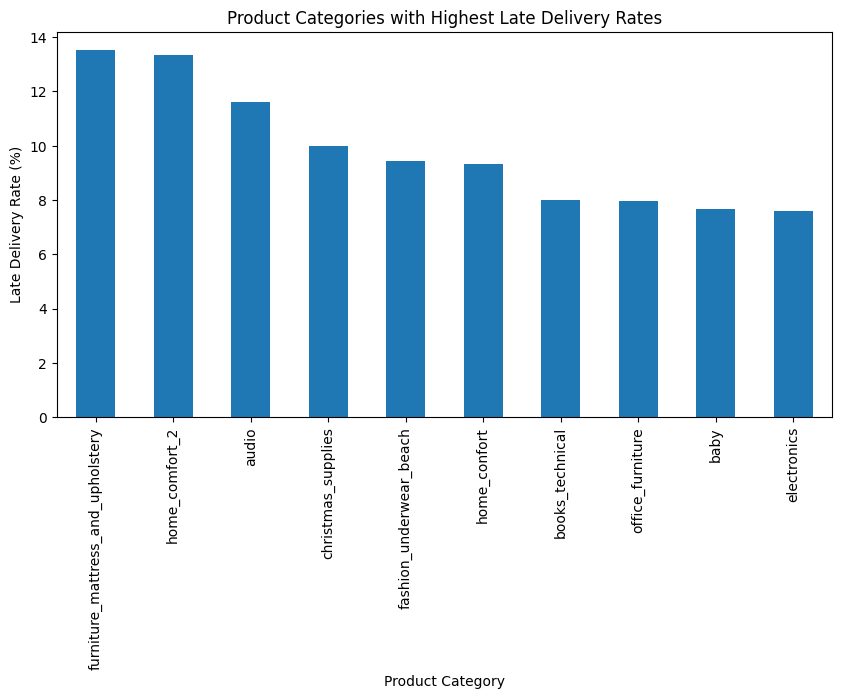

In [60]:
plt.figure(figsize=(10,5))

category_late.head(10).plot(
    kind="bar"
)

plt.title("Product Categories with Highest Late Delivery Rates")
plt.ylabel("Late Delivery Rate (%)")
plt.xlabel("Product Category")
plt.show()

Several product categories recorded noticeably lower customer satisfaction scores than the overall average review score. Categories such as security_and_services, diapers_and_hygiene, office_furniture, and home_comfort_2 received the lowest ratings, suggesting that customers purchasing these products may have experienced issues related to delivery, product quality, or service expectations.

### Product Categories with Highest Late Delivery Rates

Large and bulky product categories appear to experience higher late-delivery rates. Categories such as furniture_mattress_and_upholstery, home_comfort_2, and office_furniture recorded some of the highest delay rates. This suggests that product characteristics may influence logistics performance and that certain categories could benefit from specialized delivery planning.

### Business Value of the Additional Analysis

The product category analysis was included as an additional business-focused feature. While overall delivery performance provides a high-level view of logistics operations, category-level analysis helps identify specific products that contribute disproportionately to customer dissatisfaction and delivery delays. These insights can support targeted operational improvements, inventory planning, and specialized shipping strategies.

# 11. Key Findings and Recommendations

## Key Findings

• 93.23% of deliveries are on time, but the remaining 6.77% of late deliveries have a disproportionately large negative impact on customer satisfaction.

• Late deliveries reduce average review scores by more than 2.5 points compared to on-time deliveries, confirming a strong operational impact on customer experience.

• Delivery performance is not uniform across regions — certain states show significantly higher late delivery rates, indicating structural logistics inefficiencies rather than random delays.

• There is a clear negative correlation (-0.27) between delivery delay and customer review score, meaning as delivery delays increase, customer satisfaction consistently decreases.

• Product category analysis shows that some categories are more delay-prone and may require operational prioritization.

### Recommendations

1. Prioritize operational improvements in high-risk states with elevated late-delivery rates.

2. Review delivery forecasting models to improve the accuracy of promised delivery dates.

3. Implement proactive customer communication for shipments at risk of delay.

4. Investigate logistics processes for furniture and large-item categories, which appear to experience disproportionate delivery challenges.

5. Establish a delivery-performance monitoring dashboard to continuously track delays, customer sentiment, and regional performance trends.

### Executive KPIs

In [61]:
overall_late_rate = (
    (master_delivered["days_difference"] > 0)
    .mean()
    * 100
)

avg_review = master_delivered["review_score"].mean()

print(f"Late Delivery Rate: {overall_late_rate:.2f}%")
print(f"Average Review Score: {avg_review:.2f}")
print(f"Delivered Orders: {len(master_delivered):,}")

Late Delivery Rate: 6.77%
Average Review Score: 4.16
Delivered Orders: 96,476


Dataset for tableu

In [62]:
dashboard_df = master_category.copy()

dashboard_df.to_csv(
    "veridi_dashboard_dataset.csv",
    index=False
)

print("Export complete")

Export complete


In [63]:
from google.colab import files

files.download("veridi_dashboard_dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [64]:
master_delivered.shape

(96476, 21)

## Dashboard Export Dataset
The final dashboard dataset was exported and used to create the Tableau Public dashboard.

In [65]:
dashboard_main = master_delivered.copy()

print(dashboard_main.shape)

(96476, 21)


In [66]:
dashboard_main.to_csv(
    "veridi_main_dashboard.csv",
    index=False
)

print("Main dashboard dataset exported")

Main dashboard dataset exported


In [67]:
from google.colab import files

files.download("veridi_main_dashboard.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [68]:
dashboard_df.columns.tolist()

['order_id',
 'customer_id',
 'order_status',
 'order_purchase_timestamp',
 'order_approved_at',
 'order_delivered_carrier_date',
 'order_delivered_customer_date',
 'order_estimated_delivery_date',
 'customer_unique_id',
 'customer_zip_code_prefix',
 'customer_city',
 'customer_state',
 'review_id',
 'review_score',
 'review_comment_title',
 'review_comment_message',
 'review_creation_date',
 'review_answer_timestamp',
 'days_difference',
 'delivery_status',
 'is_late',
 'product_category_name_english']

In [69]:
dashboard_df.shape

(110196, 22)

In [70]:
dashboard_df.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'customer_unique_id', 'customer_zip_code_prefix', 'customer_city',
       'customer_state', 'review_id', 'review_score', 'review_comment_title',
       'review_comment_message', 'review_creation_date',
       'review_answer_timestamp', 'days_difference', 'delivery_status',
       'is_late', 'product_category_name_english'],
      dtype='object')

In [71]:
dashboard_df.to_csv("veridi_main_dashboard.csv", index=False)

In [72]:
from google.colab import files

files.download("veridi_main_dashboard.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>